In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [10]:
df = pd.read_csv("../data/cleaned/train_data.csv")

Plotting Class Imbalance...


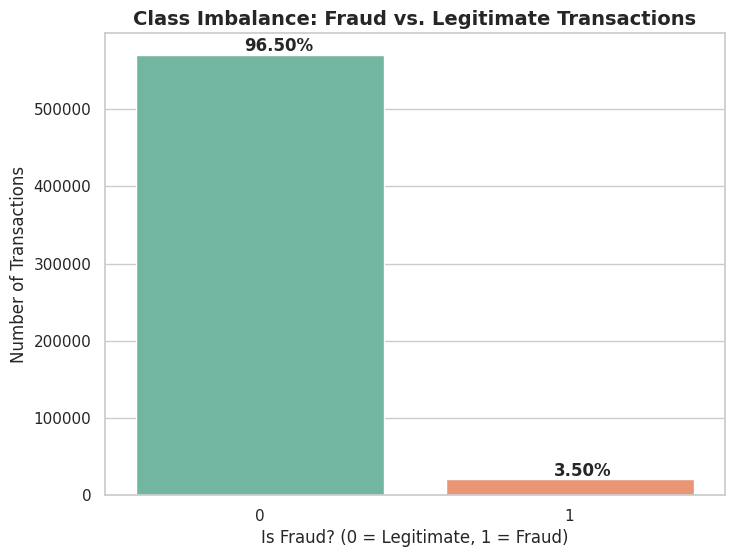

In [12]:
print("Plotting Class Imbalance...")

# Set a clean, professional theme for the paper
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

# Create the count plot
ax = sns.countplot(x='isFraud', hue="isFraud", data=df, palette='Set2', legend=False)

# Add titles and labels
plt.title('Class Imbalance: Fraud vs. Legitimate Transactions', fontsize=14, fontweight='bold')
plt.xlabel('Is Fraud? (0 = Legitimate, 1 = Fraud)', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)

# Calculate and annotate the percentages on top of the bars
total = len(df)
for p in ax.patches:
    # Calculate percentage
    percentage = f'{100 * p.get_height() / total:.2f}%'
    # Find the center of the bar for x-coordinate
    x = p.get_x() + p.get_width() / 2 - 0.05
    # Find the top of the bar for y-ccoordinate, add a little padding
    y = p.get_height() + 5000 
    ax.annotate(percentage, (x, y), size=12, fontweight='bold')

plt.show()

Plotting Correlation Heatmap...


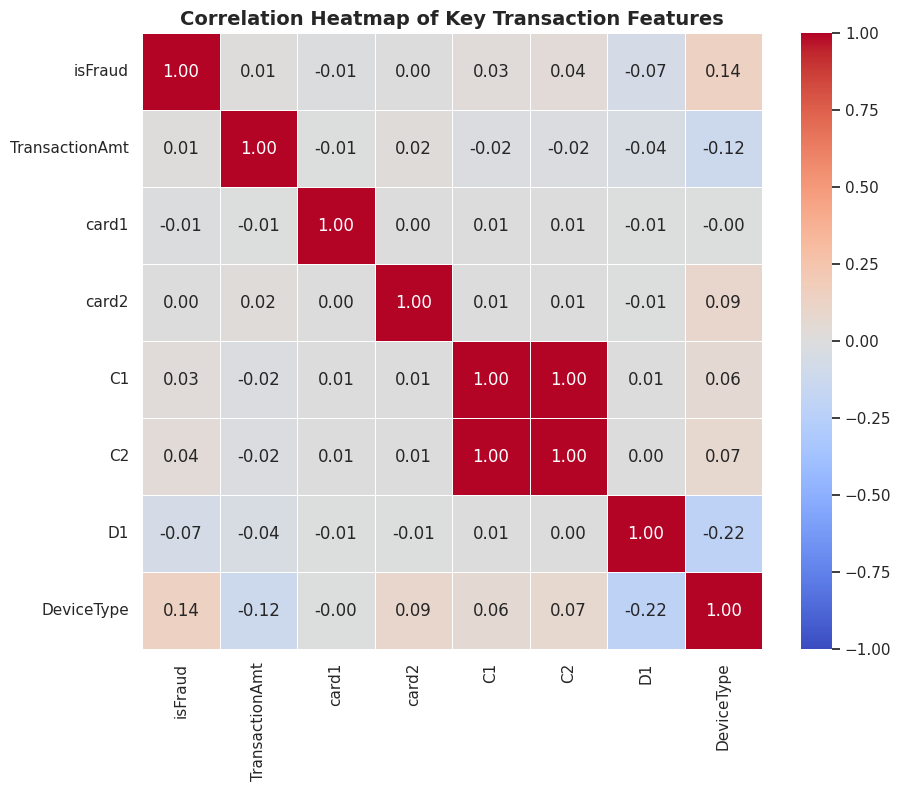

In [13]:
print("Plotting Correlation Heatmap...")

# 1. Select a targeted subset of features to keep the plot readable
subset_cols = [
    'isFraud', 'TransactionAmt', 'card1', 'card2', 
    'C1', 'C2', 'D1', 'DeviceType'
]

plt.figure(figsize=(10, 8))

# 2. Calculate the correlation matrix only for these columns
corr_matrix = df[subset_cols].corr()

# 3. Plot the heatmap
# annot=True puts the actual numbers in the boxes
# cmap='coolwarm' makes strong negative correlations blue and strong positive ones red
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)

plt.title('Correlation Heatmap of Key Transaction Features', fontsize=14, fontweight='bold')
plt.show()

Plotting the transaction amount vs hour of the day hexbin plot


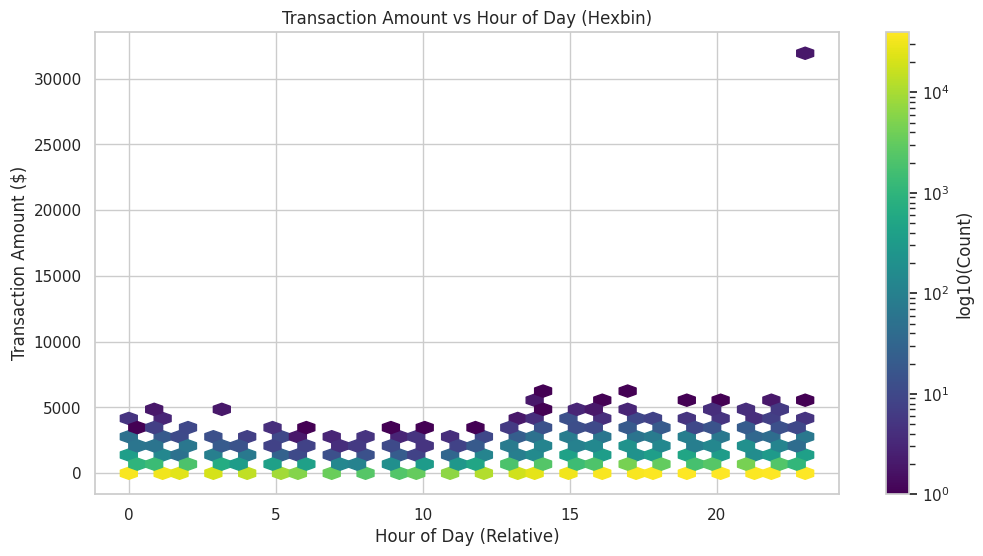

In [37]:
df["hour"] = (df["TransactionDT"] // 3600) % 24
print("Plotting the transaction amount vs hour of the day hexbin plot")
# Although seems very distributed

plt.figure(figsize=(12,6))

# Hexbin plot: x = hour, y = transaction amount
hb = plt.hexbin(
    df["hour"],
    df["TransactionAmt"],
    gridsize=40,         # number of hexagons along x-axis
    cmap='viridis',      # color map
    bins='log'           # log scale for counts (helps with skewed amounts)
)

plt.colorbar(hb, label='log10(Count)')
plt.xlabel("Hour of Day (Relative)")
plt.ylabel("Transaction Amount ($)")
plt.title("Transaction Amount vs Hour of Day (Hexbin)")
plt.show()

Plotting the transaction amount vs hour of the day kde density plot


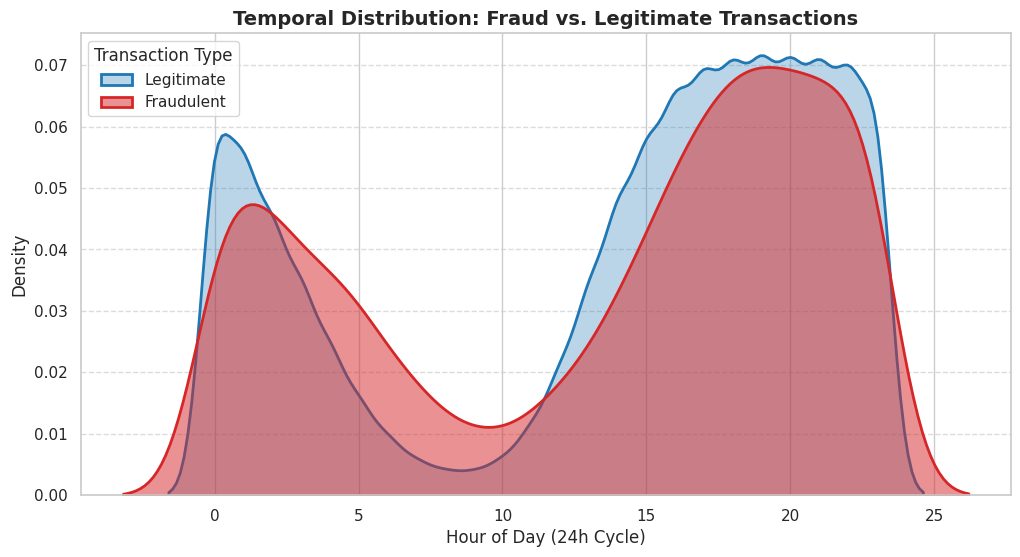

In [38]:
"""
Kde density plot normalizes both graphs
If we use normal bar graphs with 2 sticks, one fraud and one non-fraud then the non-fraud one will be too big
We won't be able to interpret the pattern of fraud transaction
It lets you compare the shape of the graphs rather than volume of it
"""
print("Plotting the transaction amount vs hour of the day kde density plot")

plt.figure(figsize=(12, 6))

# Using the modern 'fill' parameter and adding some styling
sns.kdeplot(
    data=df[df['isFraud'] == 0], x='hour', 
    label='Legitimate', fill=True, alpha=0.3, linewidth=2, color='#1f77b4'
)

sns.kdeplot(
    data=df[df['isFraud'] == 1], x='hour', 
    label='Fraudulent', fill=True, alpha=0.5, linewidth=2, color='#d62728'
)

plt.title('Temporal Distribution: Fraud vs. Legitimate Transactions', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day (24h Cycle)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(title='Transaction Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [46]:
# Trying to plot velocity of transaction by a user

# Approximate a unique cardholder
df['user_id'] = (
    df['card1'].astype(str) + '_' +
    df['card2'].astype(str) + '_' +
    df['addr1'].astype(str)
)

# Create hour-of-day feature (relative cycle)
df['hour'] = (df['TransactionDT'] // 3600) / 24  # keep total hours for velocity

# Group by user and hour
velocity = df.groupby(['user_id', 'hour', "isFraud"]).size().reset_index(name='transaction_count')

In [47]:
velocity

,user_id,hour,isFraud,transaction_count
0,10000_111.0_184.0,46.875000,0,1
1,10003_361.0_299.0,90.708333,0,1
2,10003_555.0_299.0,97.458333,0,1
3,10003_555.0_299.0,99.916667,0,2
4,10003_555.0_299.0,100.000000,0,1
...,...,...,...,...
488999,9999_174.0_330.0,162.750000,0,1
489000,9999_174.0_330.0,165.708333,0,1
489001,9999_174.0_330.0,166.625000,0,1
489002,9999_174.0_330.0,167.583333,0,1


In [48]:
velocity[velocity["isFraud"] == 1]

,user_id,hour,isFraud,transaction_count
24,10004_529.0_299.0,35.041667,1,1
117,10011_319.0_476.0,50.875000,1,1
118,10011_319.0_476.0,51.875000,1,1
120,10011_319.0_476.0,53.583333,1,1
121,10011_319.0_476.0,53.625000,1,1
...,...,...,...,...
488378,9992_455.0_310.0,98.916667,1,1
488813,9998_194.0_123.0,111.833333,1,1
488814,9998_194.0_123.0,112.625000,1,1
488985,9998_194.0_512.0,100.166667,1,1


Plotting KDE Density plot of velocity of transaction of users and fraud data


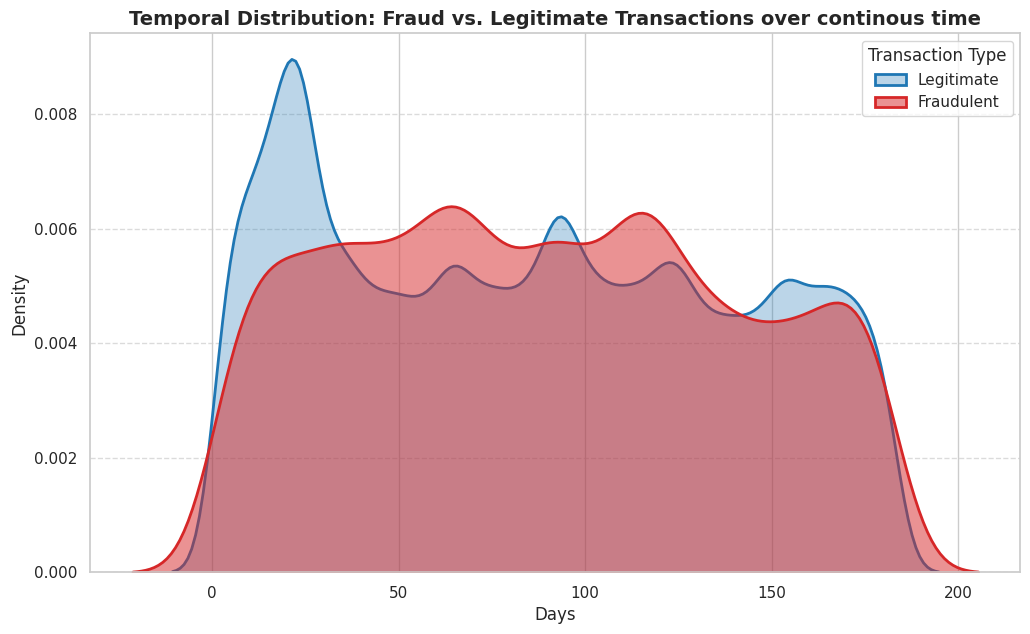

In [50]:
# We should again see a trend
print("Plotting KDE Density plot of velocity of transaction of users and fraud data")

plt.figure(figsize=(12, 7))

sns.kdeplot(
    data=velocity[velocity['isFraud'] == 0], x='hour', weights="transaction_count",
    label='Legitimate', fill=True, alpha=0.3, linewidth=2, color='#1f77b4'
)

sns.kdeplot(
    data=velocity[velocity['isFraud'] == 1], x='hour', weights="transaction_count",
    label='Fraudulent', fill=True, alpha=0.5, linewidth=2, color='#d62728'
)

plt.title('Temporal Distribution: Fraud vs. Legitimate Transactions over continous time', fontsize=14, fontweight='bold')
plt.xlabel('Days', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(title='Transaction Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()